# 🎓 From Scores to Seats: The Grad School ML Challenge

Welcome to the starter notebook for this beginner-friendly data science hackathon! In this challenge, your goal is to build a machine learning model that can predict whether a student will be admitted into a graduate program based on their academic profile.

This notebook will walk you through a simple end-to-end pipeline:
- Loading and exploring the data
- Preprocessing
- Training a baseline model
- Making predictions
- Preparing a submission

---

## 📦 Files
- `train.csv`: Training data (features + target)
- `test.csv`: Test data (features only)
- `SampleSubmission.csv`: Format for submitting predictions

---

## 🧠 Target Variable
- `Admitted`: 1 if the student was admitted, 0 otherwise

Let's get started! 🚀


In [1]:
# 📚 Importing Libraries
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import (LogisticRegression,
                                  RidgeCV,LassoCV)
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.ensemble import (StackingClassifier, BaggingClassifier,
                              GradientBoostingClassifier,
                              RandomForestClassifier, ExtraTreesClassifier,
                              AdaBoostClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report,
                             accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay)
#ignoring warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
#creating a requirement.txt file
!pip freeze > requirements.txt

In [2]:
#setting randomness
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

In [3]:
# 📥 Load the Data
train = pd.read_csv("/content/train (3).csv")
test = pd.read_csv("/content/test (4).csv")
sample_submission = pd.read_csv("/content/SampleSubmission (2).csv")

# Peek at the data
train.head()


,ID,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Admitted,Age,Location,First_Generation
0,ID_000001,319.0,111.0,4,4.78,4.89,9.51,1,1,26,South America,1
1,ID_000002,327.0,113.0,5,4.24,4.74,10.19,1,1,23,Africa,1
2,ID_000003,323.0,110.0,4,3.43,2.99,8.81,1,1,32,South America,0
3,ID_000004,321.0,105.0,3,3.41,3.38,NaN,0,0,34,Africa,1
4,ID_000005,316.0,108.0,3,NaN,4.80,NaN,1,1,30,North America,1


## 🔍 Exploratory Data Analysis (EDA)
Let’s explore the training data to understand the features and target.


In [4]:
train.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 3600 non-null   object 
 1   GRE Score          3240 non-null   float64
 2   TOEFL Score        3240 non-null   float64
 3   University Rating  3600 non-null   int64  
 4   SOP                3240 non-null   float64
 5   LOR                3600 non-null   float64
 6   CGPA               3240 non-null   float64
 7   Research           3600 non-null   int64  
 8   Admitted           3600 non-null   int64  
 9   Age                3600 non-null   int64  
 10  Location           3600 non-null   object 
 11  First_Generation   3600 non-null   int64  
dtypes: float64(5), int64(5), object(2)
memory usage: 337.6+ KB


### 🏷️ Encoding 'Location'

We used **one-hot encoding** to convert the categorical `Location` column into numeric format. This creates binary columns for each unique location (excluding one to avoid redundancy):


In [5]:
train = pd.get_dummies(train, columns=['Location'], drop_first=True)
test = pd.get_dummies(test, columns=['Location'], drop_first=True)

In [6]:
# Check for missing values
train.isnull().sum()


,0
ID,0
GRE Score,360
TOEFL Score,360
University Rating,0
SOP,360
LOR,0
CGPA,360
Research,0
Admitted,0
Age,0


In [7]:
# Fill missing numeric values with the mean of each column
numeric_cols = ['GRE Score', 'TOEFL Score', 'SOP', 'CGPA']
train[numeric_cols] = train[numeric_cols].fillna(train[numeric_cols].mean())

# Double check to confirm missing values are handled
print("Remaining missing values:", train.isnull().sum().sum())


Remaining missing values: 0


In [8]:
#stripping the 'LOR ': Remove the trailing space in the column name to avoid confusion.
train.rename(columns={'LOR ': 'LOR'}, inplace=True)
test.rename(columns={'LOR ': 'LOR'}, inplace=True)

In [9]:
train

,ID,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Admitted,Age,First_Generation,Location_Asia,Location_Europe,Location_North America,Location_South America
0,ID_000001,319.00000,111.000000,4,4.78000,4.89,9.510000,1,1,26,1,False,False,False,True
1,ID_000002,327.00000,113.000000,5,4.24000,4.74,10.190000,1,1,23,1,False,False,False,False
2,ID_000003,323.00000,110.000000,4,3.43000,2.99,8.810000,1,1,32,0,False,False,False,True
3,ID_000004,321.00000,105.000000,3,3.41000,3.38,8.576917,0,0,34,1,False,False,False,False
4,ID_000005,316.00000,108.000000,3,3.37371,4.80,8.576917,1,1,30,1,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,ID_003596,318.00000,109.000000,2,3.62000,3.99,8.760000,1,1,22,0,True,False,False,False
3596,ID_003597,313.00000,98.000000,4,3.09000,3.86,9.250000,1,1,27,0,False,False,False,True
3597,ID_003598,315.67037,118.000000,4,4.51000,3.35,9.230000,1,1,22,0,False,False,False,True
3598,ID_003599,322.00000,106.384877,5,4.04000,3.86,9.270000,1,1,27,1,False,False,True,False


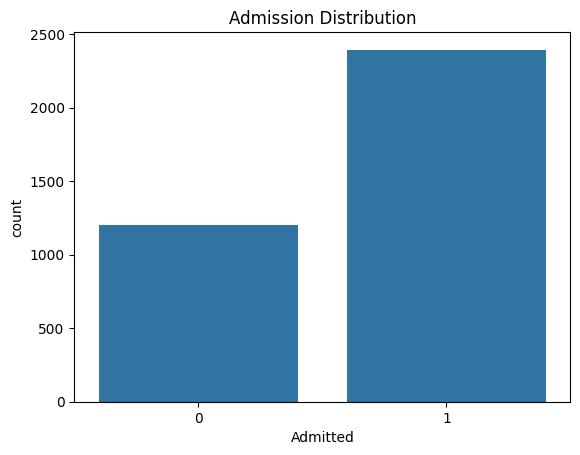

In [10]:
# Distribution of target variable
sns.countplot(x='Admitted', data=train)
plt.title("Admission Distribution")
plt.show()


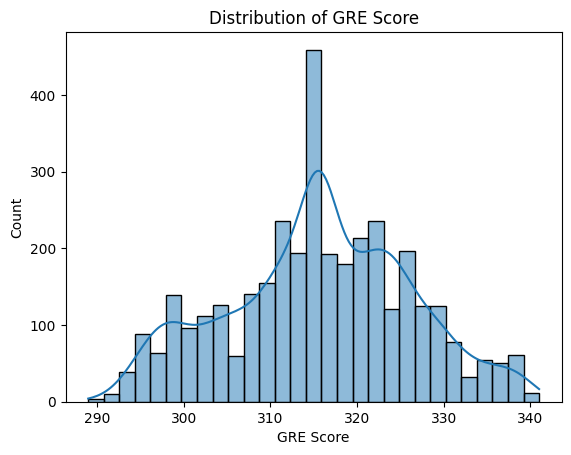

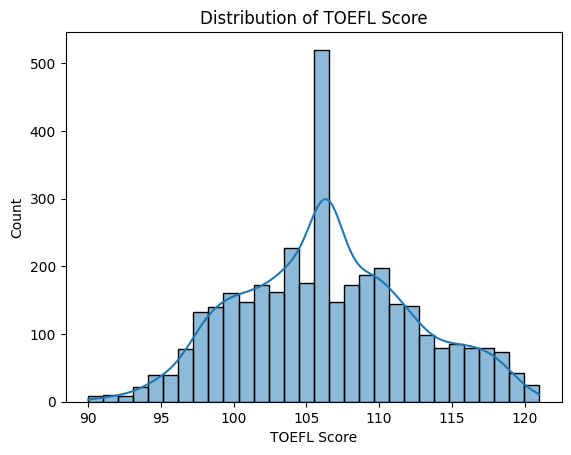

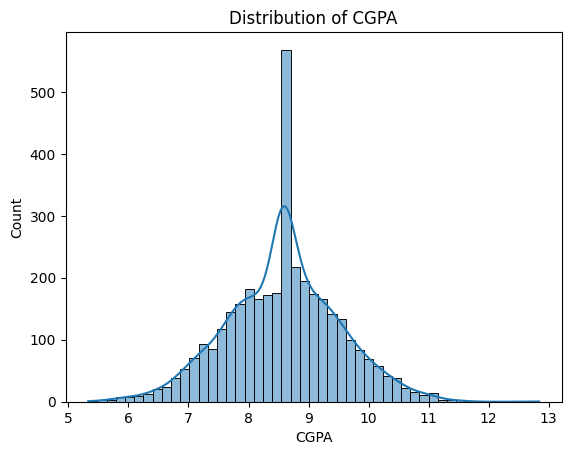

In [11]:
# Plot distributions of key features
num_features = ['GRE Score', 'TOEFL Score', 'CGPA']
for col in num_features:
    sns.histplot(train[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()


In [12]:
train

,ID,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Admitted,Age,First_Generation,Location_Asia,Location_Europe,Location_North America,Location_South America
0,ID_000001,319.00000,111.000000,4,4.78000,4.89,9.510000,1,1,26,1,False,False,False,True
1,ID_000002,327.00000,113.000000,5,4.24000,4.74,10.190000,1,1,23,1,False,False,False,False
2,ID_000003,323.00000,110.000000,4,3.43000,2.99,8.810000,1,1,32,0,False,False,False,True
3,ID_000004,321.00000,105.000000,3,3.41000,3.38,8.576917,0,0,34,1,False,False,False,False
4,ID_000005,316.00000,108.000000,3,3.37371,4.80,8.576917,1,1,30,1,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,ID_003596,318.00000,109.000000,2,3.62000,3.99,8.760000,1,1,22,0,True,False,False,False
3596,ID_003597,313.00000,98.000000,4,3.09000,3.86,9.250000,1,1,27,0,False,False,False,True
3597,ID_003598,315.67037,118.000000,4,4.51000,3.35,9.230000,1,1,22,0,False,False,False,True
3598,ID_003599,322.00000,106.384877,5,4.04000,3.86,9.270000,1,1,27,1,False,False,True,False


In [13]:
train.columns

Index(['ID', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR',
       'CGPA', 'Research', 'Admitted', 'Age', 'First_Generation',
       'Location_Asia', 'Location_Europe', 'Location_North America',
       'Location_South America'],
      dtype='object')

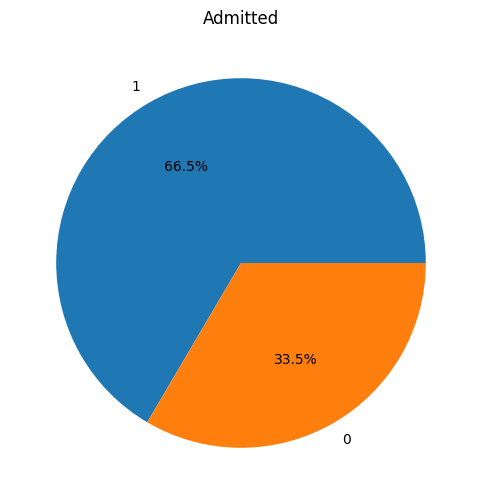

In [14]:
#plotting a pie chart for the target column -> admitted to see if there is an imbalace
plt.figure(figsize=(6,6))
plt.pie(train['Admitted'].value_counts(), labels=train['Admitted'].value_counts().index, autopct='%1.1f%%')
plt.title('Admitted')
plt.show()

The target variable -> Admitted is imbalanced since we the class - 1 contains more than 50% of the dataset

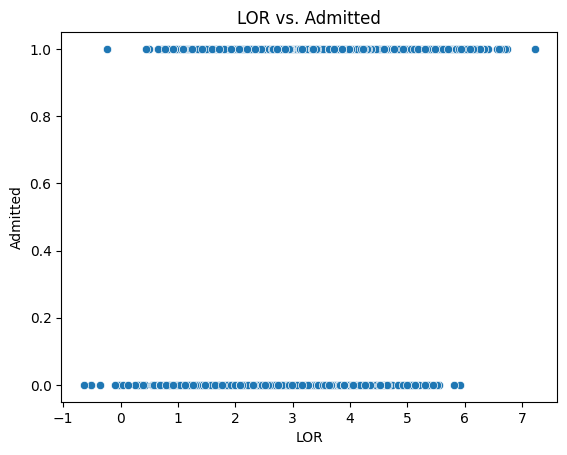

In [15]:
#interaction between the LOR column and the admitted column
sns.scatterplot(x='LOR', y='Admitted', data=train)
plt.title('LOR vs. Admitted')
plt.show()

## Feature Engineering
Removing anomalies and Creating new features for deeper insights and to ultimately improve model's performance

- Created interaction features between `Research` and `LOR`.
- Normalized `GRE` and `TOEFL` scores.
- Dropped anomalies in `CGPA` above 10.0.



In [16]:
# Check for rows where CGPA is greater than 10.0
anomalies = train[train['CGPA'] > 10.0]

#showing the count of columns with CGPA greater than 10.0
print("Number of CGPA values > 10.0:", len(anomalies))
print("Maximum CGPA value in the dataset:", train['CGPA'].max())

Number of CGPA values > 10.0: 240
Maximum CGPA value in the dataset: 12.84


In [17]:
anomalies_test = test[test['CGPA'] > 10.0]
#print(anomalies_test)
#showing the count of columns with CGPA greater than 10.0
print("Number of CGPA values > 10.0:", len(anomalies_test))
print("Maximum CGPA value in the dataset:", test['CGPA'].max())

Number of CGPA values > 10.0: 59
Maximum CGPA value in the dataset: 11.52


In [18]:
#Clip CGPA at 10.0
train['CGPA'] = train['CGPA'].clip(upper=10.0)
test['CGPA'] = test['CGPA'].clip(upper=10.0)

In [19]:
#checking to see if CGPA has been clipped to 10.0
print("Maximum CGPA value in the dataset:", train['CGPA'].max())
print("Maximum CGPA value in the dataset:", test['CGPA'].max())

Maximum CGPA value in the dataset: 10.0
Maximum CGPA value in the dataset: 10.0


In [20]:
#GRE_TOEFL Ratio -> might hint at a student balance in skills
train['GRE_TOEFL_Ratio'] = train['GRE Score'] / train['TOEFL Score']
test['GRE_TOEFL_Ratio'] = test['GRE Score'] / test['TOEFL Score']

In [21]:
#Interaction between Research and LOR (strong letter may carry more weight for researchers)
train['Research_LOR'] = train['Research'] * train['LOR']
test['Research_LOR'] = test['Research'] * test['LOR']

In [22]:
#average strength of the letter of recommendation and statement of purpose
train['SOP_LOR_Avg'] = (train['SOP'] + train['LOR']) / 2
test['SOP_LOR_Avg'] = (test['SOP'] + test['LOR']) / 2

## 🧹 Preprocessing
We’ll split the data into features and target, use SMOTE to ensure a balance in the target variable and then into training and validation sets.


In [60]:
#randomness
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Features and target
X = train.drop(columns=['Admitted', "ID"])
y = train['Admitted']


smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Split into train/validation
X_train, X_val, y_train, y_val = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

#scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

X_train.shape, X_val.shape


((3832, 16), (958, 16))

## 🤖 Model Training
I will use a list of models and then use a stacking classifier to combine for better results.

In [61]:
# Train a Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=2,
    random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(min_samples_leaf=2, random_state=42)

In [62]:
#using cross validation to get the average performance of the random forest model
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
print("F1 Score:", scores.mean())

F1 Score: 0.9002966228318293


In [63]:
#setting up lgbmclassifier
lgbm = LGBMClassifier(n_estimators=80, random_state=42)
lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 1929, number of negative: 1903
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000699 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2065
[LightGBM] [Info] Number of data points in the train set: 3832, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503392 -> initscore=0.013570
[LightGBM] [Info] Start training from score 0.013570


LGBMClassifier(n_estimators=80, random_state=42)

In [64]:
#bagging classifier for lgbm2
bag_lgb = BaggingClassifier(estimator=lgbm, n_estimators=10, random_state=42)
bag_lgb.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 1929, number of negative: 1903
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000695 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2065
[LightGBM] [Info] Number of data points in the train set: 3832, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.514092 -> initscore=0.056382
[LightGBM] [Info] Start training from score 0.056382
[LightGBM] [Info] Number of positive: 1929, number of negative: 1903
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001164 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2065
[LightGBM] [Info] Number of data points in the train set: 3832, number of used features: 16
[LightGBM] [Info] [binary:

BaggingClassifier(estimator=LGBMClassifier(n_estimators=80, random_state=42),
                  random_state=42)

In [65]:
#gradientboosting classifer
gb = GradientBoostingClassifier(max_depth=10)
gb.fit(X_train, y_train)

GradientBoostingClassifier(max_depth=10)

In [66]:
#logistic regression
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [67]:
#adaboost classifier
ada = AdaBoostClassifier(n_estimators=80, random_state=42)
ada.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=80, random_state=42)

In [68]:
#lassocv -> for regularization strength
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train, y_train)

LassoCV(cv=5, random_state=42)

In [69]:
#ridgecv -> for regularization strength
ridge = RidgeCV(cv=5)
ridge.fit(X_train, y_train)

RidgeCV(cv=5)

In [70]:
#extratreeclassifier
etc = ExtraTreesClassifier(n_estimators=80,
                           max_depth=10,
                           random_state=42)
etc.fit(X_train, y_train)

ExtraTreesClassifier(max_depth=10, n_estimators=80, random_state=42)

In [71]:
#decisiontreeclassifier
dtc = DecisionTreeClassifier(max_depth=10, random_state=42)
dtc.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [72]:
#svr classifier
svc = SVC(
    C=1.0,
    kernel='rbf',
    degree=3,
    gamma='scale',
    probability=True,
    random_state=42
)
svc.fit(X_train, y_train)

SVC(probability=True, random_state=42)

In [73]:
#bagging classifier for gradientboosting
bag_gbc = BaggingClassifier(estimator=gb, n_estimators=10, random_state=42)
bag_gbc.fit(X_train, y_train)

BaggingClassifier(estimator=GradientBoostingClassifier(max_depth=10),
                  random_state=42)

In [74]:
#stacking classifier
estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('lgbm', lgbm),
    ('lr', lr),
    ('bag_lgb', bag_lgb),
    ('clf', gb),
    ('ada', ada),
    ('lasso', lasso),
    ('ridge', ridge),
    ('svc', svc),
    ('etc', etc)
]

stacking_model = StackingClassifier(estimators=estimators,
                                    final_estimator=lr,
                                    cv=5,
                                    passthrough=True)

stacking_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 1929, number of negative: 1903
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000617 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2065
[LightGBM] [Info] Number of data points in the train set: 3832, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503392 -> initscore=0.013570
[LightGBM] [Info] Start training from score 0.013570
[LightGBM] [Info] Number of positive: 1929, number of negative: 1903
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000565 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2065
[LightGBM] [Info] Number of data points in the train set: 3832, number of used features: 16
[LightGBM] [Info] [binary:

StackingClassifier(cv=5,
                   estimators=[('rf', RandomForestClassifier(random_state=42)),
                               ('lgbm',
                                LGBMClassifier(n_estimators=80,
                                               random_state=42)),
                               ('lr',
                                LogisticRegression(class_weight='balanced',
                                                   max_iter=1000)),
                               ('bag_lgb',
                                BaggingClassifier(estimator=LGBMClassifier(n_estimators=80,
                                                                           random_state=42),
                                                  random_state=42)),
                               ('clf',
                                GradientBoostingClassifier(max_depth=10)),
                               ('ada',
                                AdaBoostClassifier(n_estimators=80,
                                                   random_state=42)),
                               ('lasso', LassoCV(cv=5, random_state=42)),
                               ('ridge', RidgeCV(cv=5)),
                               ('svc', SVC(probability=True, random_state=42)),
                               ('etc',
                                ExtraTreesClassifier(max_depth=10,
                                                     n_estimators=80,
                                                     random_state=42))],
                   final_estimator=LogisticRegression(class_weight='balanced',
                                                      max_iter=1000),
                   passthrough=True)

In [75]:
#evaluation

y_pred_prob = stacking_model.predict_proba(X_val)[:, 1]
y_pred = (y_pred_prob >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_val, y_pred))

Accuracy: 0.907098121085595


Accuracy: 0.907098121085595

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.91       492
           1       0.93      0.87      0.90       466

    accuracy                           0.91       958
   macro avg       0.91      0.91      0.91       958
weighted avg       0.91      0.91      0.91       958



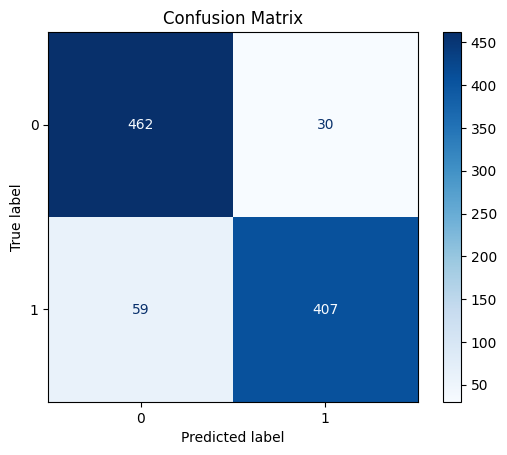

In [76]:
# 📈 Evaluate Model on Validation Set


# Predict on validation data
y_pred_probs = stacking_model.predict(X_val)

# Convert probabilities to binary predictions using a threshold -> 0.5
y_pred = (y_pred_probs >= 0.5).astype(int)

# Accuracy score
print("Accuracy:", accuracy_score(y_val, y_pred))

# Classification report
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


## 📊 Feature Importance
Let’s see which features are most important to the model.

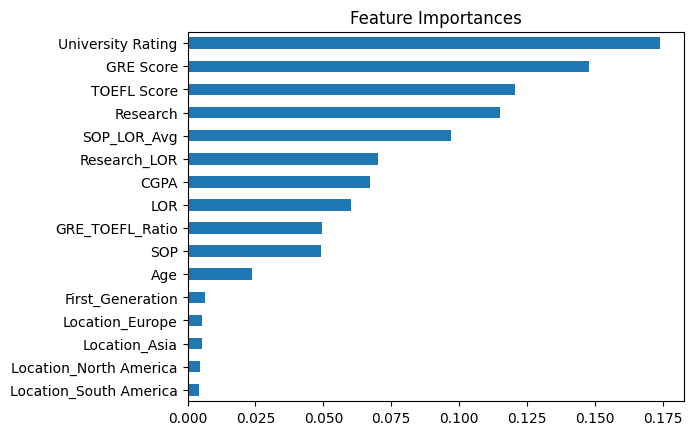

In [40]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.title("Feature Importances")
plt.show()


## 🚀 Predictions on Test Set
Let’s predict on the test set and generate a submission file.


In [41]:
test.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Age,First_Generation,ID,Location_Asia,Location_Europe,Location_North America,Location_South America,GRE_TOEFL_Ratio,Research_LOR,SOP_LOR_Avg
0,323.0,110.0,3,3.49,3.72,9.50,1,24,0,ID_003601,False,False,False,True,2.936364,3.72,3.605
1,324.0,111.0,4,4.32,3.84,8.86,1,23,0,ID_003602,True,False,False,False,2.918919,3.84,4.080
2,311.0,104.0,2,4.38,1.84,7.21,1,24,1,ID_003603,True,False,False,False,2.990385,1.84,3.110
3,323.0,109.0,4,4.92,3.81,10.00,1,27,0,ID_003604,False,False,True,False,2.963303,3.81,4.365
4,321.0,111.0,4,4.00,5.99,8.59,1,29,1,ID_003605,False,False,True,False,2.891892,5.99,4.995


In [42]:
# Get the column names used during training
training_columns = X.columns

# Ensure the test DataFrame has the same columns in the same order
test = pd.DataFrame(test, columns=training_columns)

# Before scaling the test data, impute missing values
imputer = SimpleImputer(strategy='mean')
test = imputer.fit_transform(test)

test = scaler.transform(test)

In [77]:
#making predictions on the test data
test_predictions = stacking_model.predict(test)

# Prepare submission
submission = sample_submission.copy()
submission['Admitted'] = test_predictions

# Save to CSV
submission.to_csv('submission_9.csv', index=False)
print("Submission file saved!")


Submission file saved!


# From Scores to Seats: Grad School ML Challenge
**Date**: 5 April 2025  

This notebook contains the complete solution for predicting student admissions into graduate programs. The pipeline includes data preprocessing, feature engineering, model selection, and prediction generation for submission.

## ✅ What’s Next?

This is just a baseline model! You can improve your score by:
- Trying other models (Logistic Regression, XGBoost, etc.)
- Feature scaling or transformation
- Hyperparameter tuning
- Model ensembling

Good luck, and happy modeling! 💪


### Hosts: Olufemi Victor Tolulope & Olaleye Eniola

Victor's Socials:

- [Twitter](https://twitter.com/olufemivictort)
- [LinkedIn](https://www.linkedin.com/in/olufemi-victor-tolulope)
- [website](https://www.olufemivictor.com/)

Eniola's Socials
- [Twitter](https://x.com/galileoeni)
- [LinkedIn](https://www.linkedin.com/in/eniola-olaleye-361b39160)
- [website](https://galileoeni.github.io/galileo/)